# T01 — Hello, deep time

**A first paleo-geographic map rendered with GPlately + pyGMT.** This is the anchor tutorial for the GPlately × pyGMT integration.

## What this notebook produces

A single global paleo-geographic map at 50 Ma — Robinson projection, with reconstructed continents, coastlines, mid-ocean ridges, transforms, and subduction zones drawn from the Zahirovic et al. (2022) plate model. An optional bonus cell at the end renders the same snapshot through Cartopy so you can compare the two cartographic stacks side by side.

## What you will learn

1. How to load a published plate-motion model via the [Plate Model Manager](https://pypi.org/project/plate-model-manager/) and inspect what files come with it.
2. How to build a `gplately.PlateReconstruction` and a `gplately.PlotTopologies` snapshot at a target reconstruction time.
3. How to push those geometries onto a `pygmt.Figure` via `gplately.PygmtPlotEngine`, with the suite-standard continuous topology backbone and styled ridges / trenches on top.
4. (Optional) How the same data renders through GPlately's default matplotlib / Cartopy engine, and why pyGMT is usually the better choice for publication figures.

**Audience**: undergraduate / new-to-GPlately.  
**Prerequisites**: a `gplately` conda environment that also includes `pygmt`. Internet access is required on first run so that `plate_model_manager` can download and cache the Zahirovic 2022 plate model.  
**Runtime**: ≈30 seconds on first run, ≈10 seconds thereafter.

## Learning objectives

- Install GPlately + pyGMT and confirm versions in cell 1.
- Fetch a plate model with `plate_model_manager` (no manual download).
- Render a global paleo-Earth map at a chosen reconstruction age with continents, coastlines, and topological plate boundaries.
- Recognise the continuous-backbone pattern for drawing complete plate-boundary networks.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022 (default for the suite).
- **Reconstruction time**: 50 Ma snapshot (change to taste).
- **Python**: `gplately`, `pygmt`, `pygplates`, `plate_model_manager`.
- **Runtime**: < 1 minute on a laptop; first run downloads the plate model (~50 MB).


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports and version check
import gplately
import pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

print(f"gplately         {gplately.__version__}")

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")
print(f"pygmt            {pygmt.__version__}")
print()
print("Full pyGMT / GMT stack:")
pygmt.show_versions()

gplately         2.0.0.post19+git.2cce7bb3
pygmt            v0.18.0

Full pyGMT / GMT stack:
PyGMT information:
  version: v0.18.0
System information:
  python: 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:32:50) [Clang 16.0.6 ]
  executable: /opt/miniconda3/bin/python
  machine: macOS-26.5.1-arm64-arm-64bit
Dependency information:
  numpy: 2.3.2
  pandas: 2.2.3
  xarray: 2026.4.0
  packaging: 24.2
  contextily: None
  geopandas: 1.0.1
  IPython: 8.12.3
  pyarrow: 21.0.0
  rioxarray: 0.18.2
  gdal: 3.10.3
  ghostscript: 9.56.1
GMT library information:
  version: 6.5.0
  padding: 2
  share dir: /opt/miniconda3/share/gmt
  plugin dir: /opt/miniconda3/lib/gmt/plugins
  library path: /opt/miniconda3/lib/libgmt.dylib
  cores: 16
  grid layout: rows
  image layout: 
  binary version: 6.5.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
RECONSTRUCTION_TIME  = 50.0          # Ma — the snapshot rendered below
ANCHOR_PLATE_ID      = 0             # 0 = mantle reference frame
# ============================================================================


## 1. Load a published plate motion model

`PlateModelManager` is a one-call download manager for published reconstructions. The first time you call `get_model`, it downloads and unpacks the model archive into `data_dir`. Subsequent calls reuse the cache.

We use **Zahirovic et al. (2022)** as the default model throughout this tutorial suite. It covers ≈410 Ma to present at 1-Myr resolution, has self-consistent topological plate boundaries, and is the standard reference for deep-time work in the EarthByte group.

In [3]:
# Cell 2 — fetch the Zahirovic 2022 model
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

# PMM models expose get_avail_layers() — the canonical way to list what's
# in a model. Cleaner than iterating through a hardcoded list of getter
# names and trying each one.
print(f"Layers available in the {MODEL_NAME} model:")
for layer in model.get_avail_layers():
    print(f"  • {layer}")

Layers available in the Zahirovic2022 model:
  • Coastlines
  • StaticPolygons
  • ContinentalPolygons
  • Topologies
  • COBs


## 2. Build the reconstruction and a 50 Ma snapshot

`PlateReconstruction` wraps the rotation model + topology features and provides the kinematic backbone (point reconstructions, velocity calculations, distances). `PlotTopologies` is a *time-pinned* snapshot — give it a reconstruction time and it exposes the coastlines, COBs, and topology geometries for that age as GeoDataFrames you can hand to any plotting library.

In [4]:
# Cell 3 — build PlateReconstruction + PlotTopologies @ 50 Ma
RECONSTRUCTION_TIME = 50  # Ma

reconstruction = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# Pass the pyGMT plotting engine into PlotTopologies so gplot.plot_X(fig, ...)
# methods used in Cell 4 below dispatch to pyGMT internally. The API matches
# the Cartopy variant in Cell 5 — same gplot.plot_continents(ax, ...) /
# gplot.plot_continents(fig, ...) calls, only the target object differs.
gplot = gplately.PlotTopologies(
    plate_reconstruction=reconstruction,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=RECONSTRUCTION_TIME,
    plot_engine=gplately.PygmtPlotEngine(),
)

print(f"Reconstruction time: {gplot.time} Ma")

Reconstruction time: 50.0 Ma


## 3. Render the 50 Ma snapshot with pyGMT

We push the GeoDataFrames returned by `PlotTopologies` onto a `pygmt.Figure` via `gplately.PygmtPlotEngine`. The figure layers, in draw order:

- **Continents** — grey fill (`gray95`) with a thin dark-grey outline.
- **Coastlines** — dark-grey lines on top of the continent fill.
- **Continuous plate-boundary backbone** — every resolved boundary segment in mid-grey, so ridges, transforms and trenches share a consistent base.
- **Mid-ocean ridges** — bright red lines layered on top of the backbone.
- **Transforms** — goldenrod lines.
- **Subduction zones** — blue lines with GMT "teeth" on the upper-plate side.

*Note on figure size.* `20c` sets the **paper** width of the map — i.e. the size it would have if you ran `fig.savefig("map.pdf")` and printed the PDF. The size you see *on screen* in the notebook is controlled separately by the inline preview width. By default pyGMT renders the preview at about 500 pixels wide, which on a high-DPI display looks roughly half the paper size. We pass `width=900` to `fig.show()` below to bring the preview close to its true 20 cm.

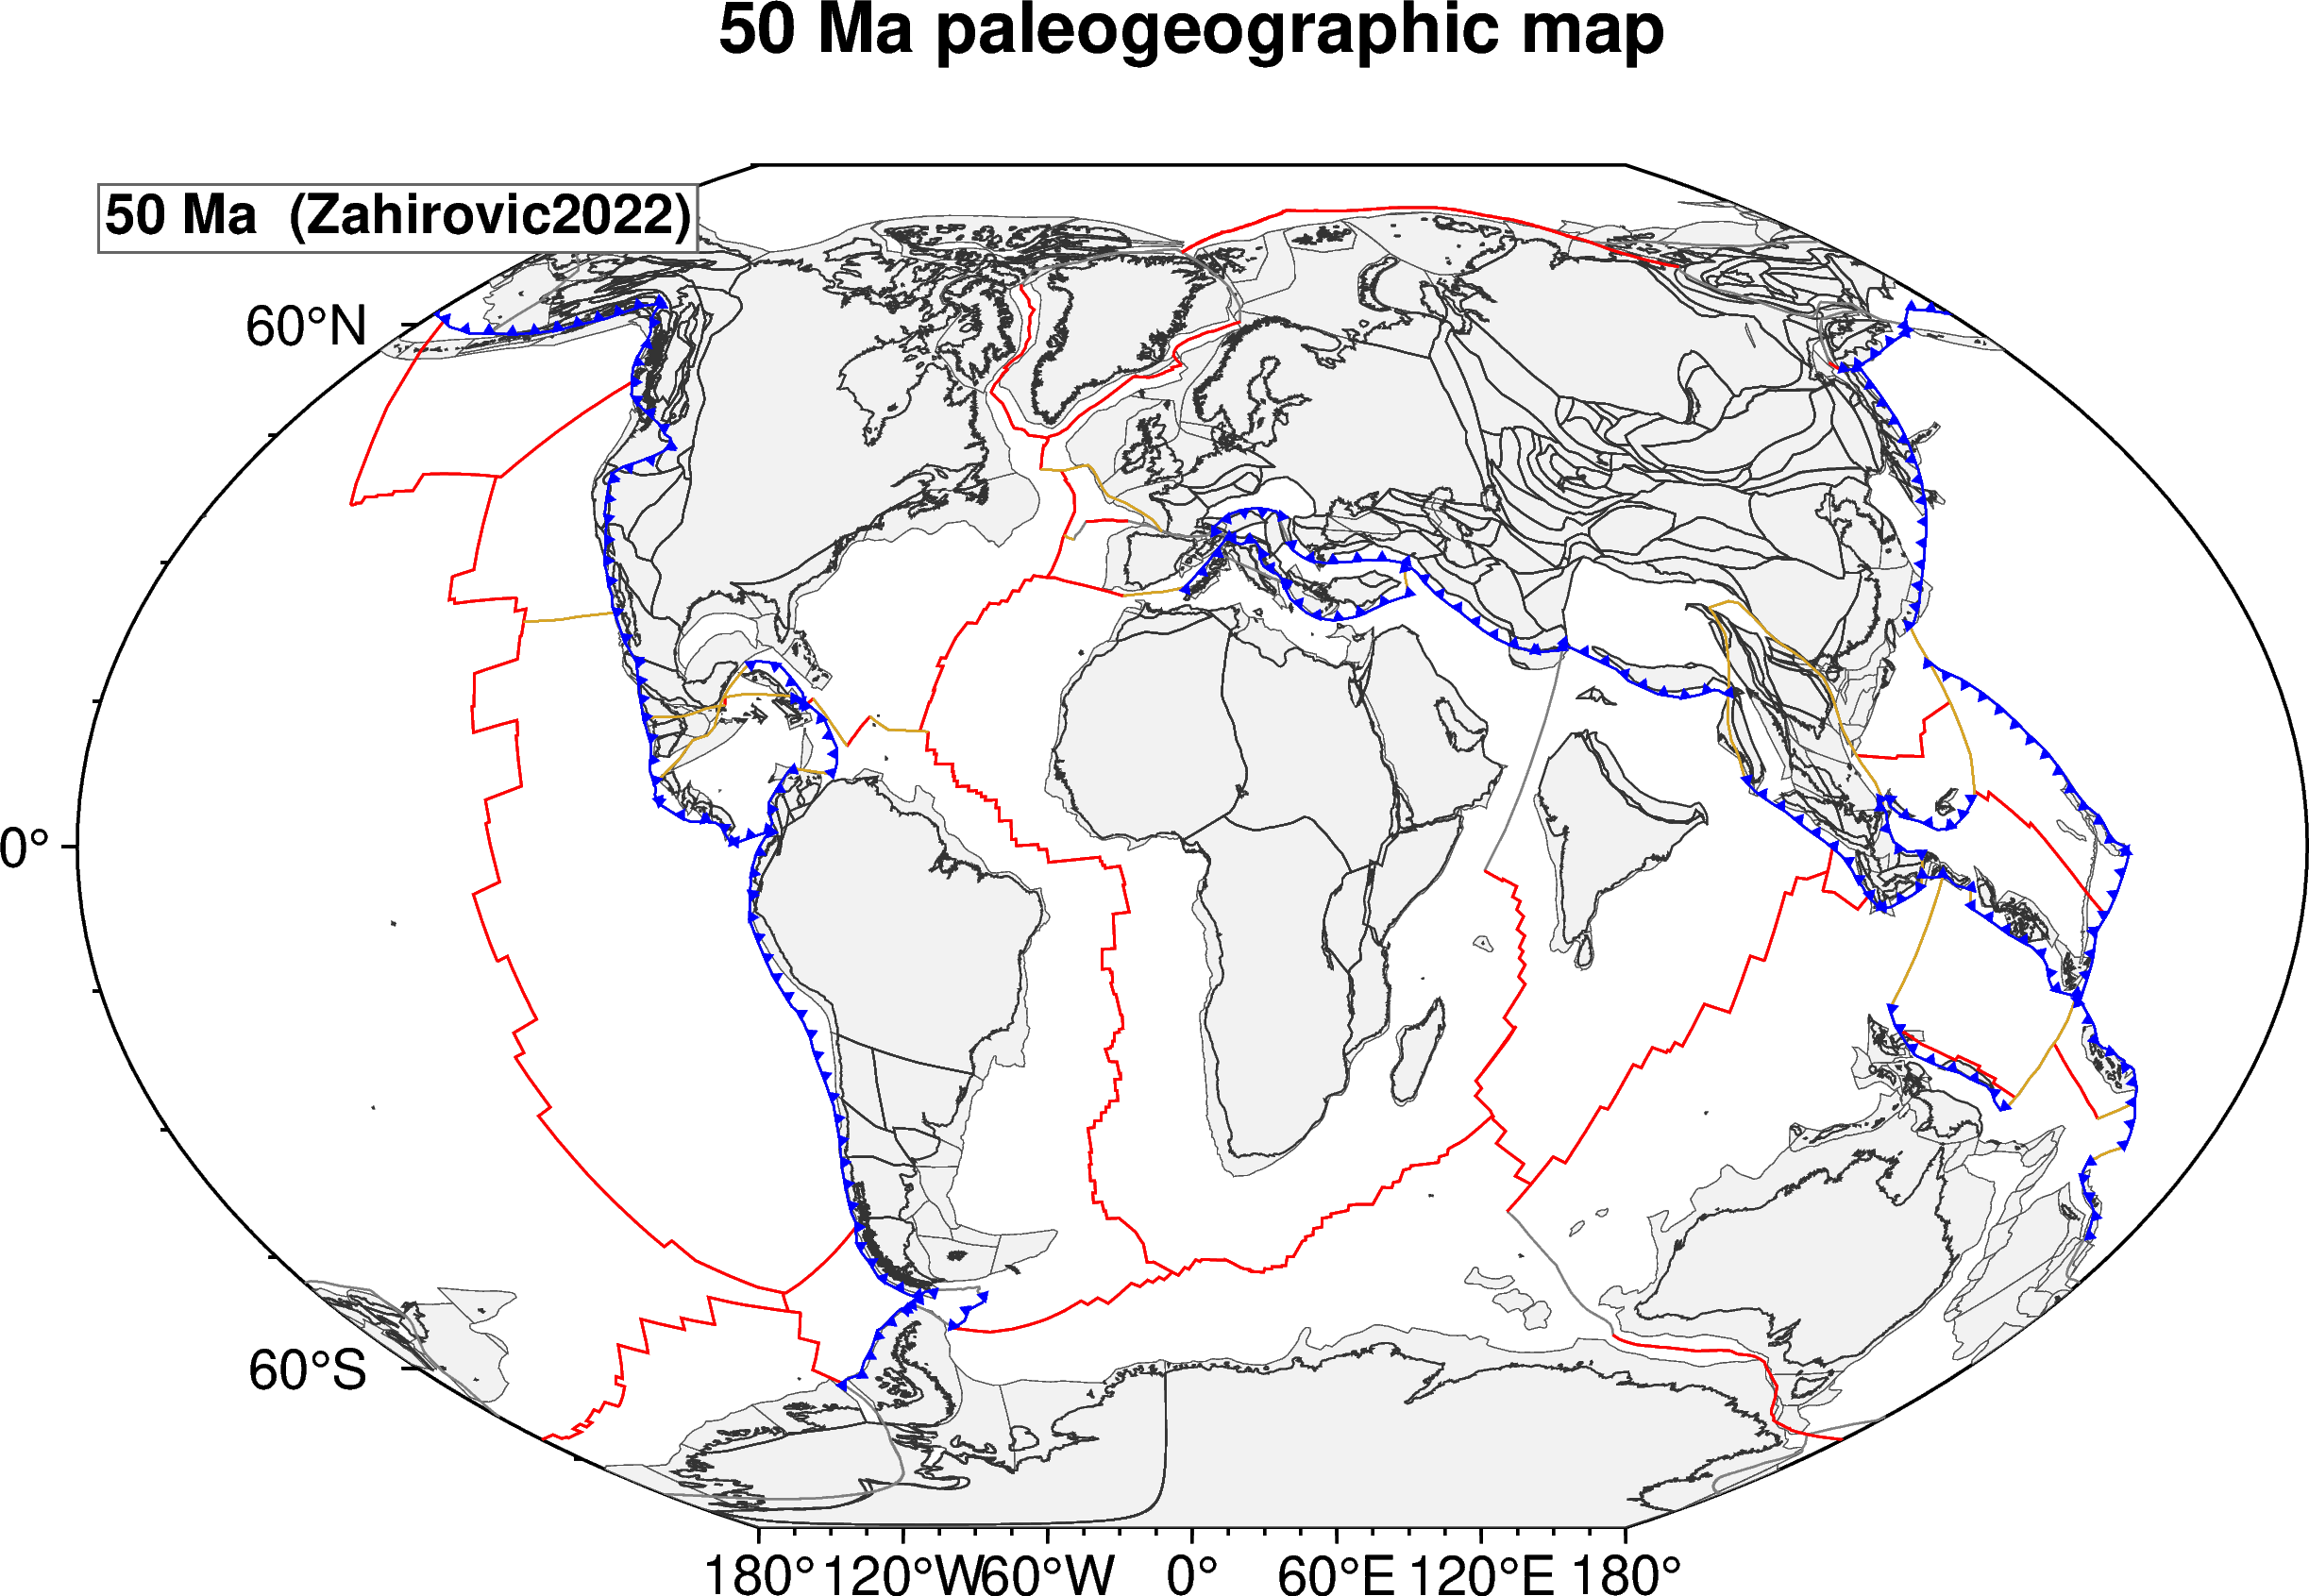

In [5]:
# Cell 4 — render a paleo-map with pyGMT.
# PlotTopologies was built in Cell 3 with plot_engine=PygmtPlotEngine(),
# so gplot.plot_X(fig, ...) calls dispatch to pyGMT internally — the same
# API shape as the Cartopy cell below, just with a pyGMT Figure target.
fig = pygmt.Figure()

fig.basemap(
    region="d",                          # whole globe
    projection="R0/20c",                 # Robinson, 20 cm wide
    frame=["af", f'+t{RECONSTRUCTION_TIME} Ma paleogeographic map'],
)

# Continents (filled)
gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray30")

# Coastlines (line)
gplot.plot_coastlines(fig, pen="0.4p,gray20")

# Continuous plate-boundary backbone (incl. "other" segments
# that aren't classified as ridge / transform / subduction — these are
# the connection points that would otherwise leave gaps in the network).
# Draw this FIRST so ridges, transforms and trenches render on top with
# their distinctive colours. Pattern follows the Dixon A24 reference.
gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")

# Mid-ocean ridges
gplot.plot_ridges(fig, pen="0.6p,red")

# Transforms
gplot.plot_transforms(fig, pen="0.5p,goldenrod")

# Subduction zones (with GMT "teeth" rendered by the pyGMT engine)
gplot.plot_subduction_teeth(fig, color="blue")

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=900)

display(HTML('<div style="height:1cm"></div>'))

### What the 50 Ma map shows

Look at where each continent has been rotated. At 50 Ma:

- **India** is still ≈1500 km south of Asia — the Tethys is open and active Tethyan subduction zones cut across what is now southern Asia.
- **Australia** has just begun pulling away from Antarctica; the Southern Ocean is a narrow strip.
- **The North Atlantic** is open from the Bay of Biscay northward, but Greenland still sits close to Norway.
- **The Drake Passage** between South America and Antarctica is closed or only barely open.
- **The Pacific** is dominated by the Izanagi-Farallon-Kula plate system; spreading ridges (red) cut a long zig-zag across the basin and subduction zones (blue with teeth) ring the Pacific margins on both sides.

The grey "backbone" lines that connect the red ridges and blue trenches are the "other" topology segments — the connection points that close each resolved plate polygon. Drawing this layer first makes the boundary network look continuous instead of broken.

## 4. (Optional) Side-by-side with Cartopy

For comparison: the *same* `PlotTopologies` object can render through GPlately's default matplotlib/Cartopy engine. Run the cell below to see the difference. Notice that pyGMT typically renders cleaner subduction teeth, sharper line work, and more publication-friendly typography out of the box.

Skip this cell if you don't have Cartopy installed — it isn't required for any of the other tutorials.

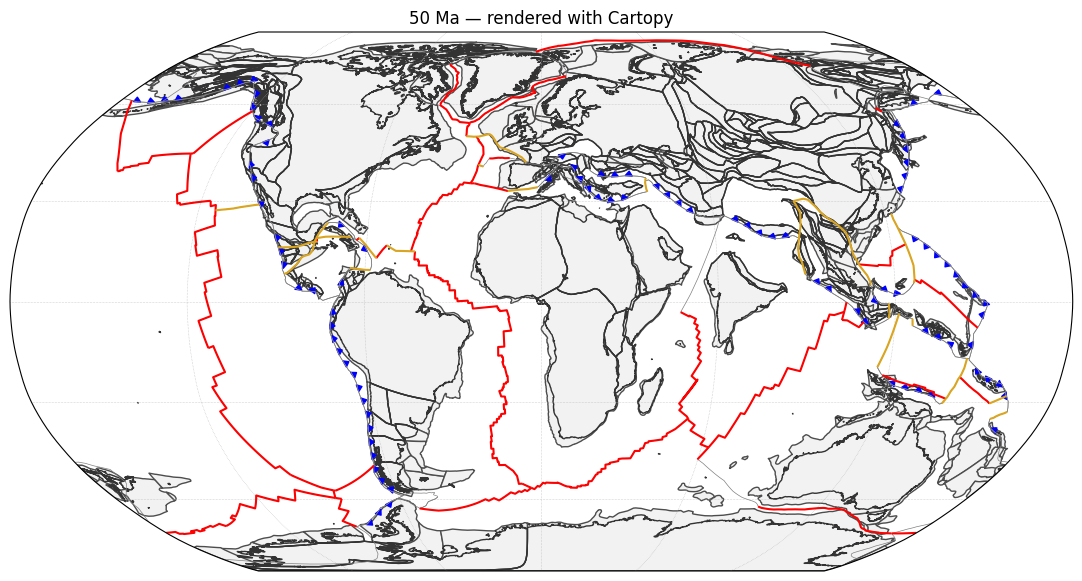

In [6]:
# Cell 5 — same 50 Ma snapshot, rendered with Cartopy for comparison
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# `gplot` in Cell 3 was bound to PygmtPlotEngine for the pyGMT render in
# Cell 4. The plot-engine dispatch is fixed at PlotTopologies construction
# time, so to render through Cartopy we need a second snapshot — same
# inputs, but with plot_engine OMITTED so it defaults to the Cartopy /
# matplotlib backend.
gplot_cp = gplately.PlotTopologies(
    plate_reconstruction=reconstruction,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=RECONSTRUCTION_TIME,
)

fig_cp, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=0)},
)
ax.set_global()
ax.gridlines(linestyle=":", linewidth=0.4)
ax.set_title(f"{RECONSTRUCTION_TIME} Ma — rendered with Cartopy")

# Note: Cartopy uses matplotlib colour names, not GMT's. Greyscale strings
# like "0.3" map to the GMT "gray30" tone.
gplot_cp.plot_continents(ax, facecolor="0.95", edgecolor="0.3")
gplot_cp.plot_coastlines(ax, color="0.2")
# Continuous topology backbone first (catches the "other" connection segments)
gplot_cp.plot_all_topological_sections(ax, color="0.5", linewidth=0.5)
gplot_cp.plot_ridges(ax, color="red")
gplot_cp.plot_transforms(ax, color="goldenrod")
gplot_cp.plot_subduction_teeth(ax, color="blue")

plt.show()

## What the map tells us

The 50 Ma snapshot is a particular moment in the Cenozoic re-organisation of plate boundaries. Spend a minute reading what's happening in each ocean basin — Tethyan subduction, Atlantic opening, Indian-Ocean spreading — and notice how different the Pacific looks with Izanagi still alive. This is exactly the kind of context that motivates deep-time work in everything that follows in the suite.

## Extend this

A few directions to try:

- **Change the time.** Set `RECONSTRUCTION_TIME = 200` for Pangaea, `100` for the mid-Cretaceous, `0` for present-day.
- **Change the projection.** Replace `R0/20c` with `W0/20c` (Mollweide), `H0/20c` (Hammer), `G0/0/20c` (orthographic from 0°N 0°E), or `S0/-90/20c` (south polar stereographic). See pyGMT's [projections reference](https://www.pygmt.org/latest/projections/index.html).
- **Add Earth relief.** Drape `pygmt.datasets.load_earth_relief("10m")` underneath the paleo-coastlines. See **T16**.
- **Animate.** Wrap this whole notebook in a loop over `range(0, 201, 5)` and assemble the frames into a GIF. That's exactly the recipe in **T06**.

Notebooks that build directly on this one: **T03** (projection cookbook), **T14** (velocity vectors on the same basemap), **T14–T16** (reconstructed zircon datasets plotted with the same engine).

*Note on figure size.* `20c` sets the **paper** width of the map — i.e. the size it would have if you ran `fig.savefig("map.pdf")` and printed the PDF. The size you see *on screen* in the notebook is controlled separately by the inline preview width. By default pyGMT renders the preview at about 500 pixels wide, which on a high-DPI display looks roughly half the paper size. We pass `width=900` to `fig.show()` below to bring the preview close to its true 20 cm.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Müller, R.D., Cannon, J., Qin, X., Watson, R.J., Gurnis, M., Williams, S., Pfaffelmoser, T., Seton, M., Russell, S.H.J. & Zahirovic, S. (2018). GPlates: Building a virtual Earth through deep time. *Geochem. Geophys. Geosys.* 19, 2243-2261. https://doi.org/10.1029/2018GC007584
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146